# How to upscale our element maps?

In [10]:
import falnama
import maxrf4u as mx
import matplotlib.pyplot as plt

In [3]:
datastack_files = falnama.Falnama_maxrf_data().get_datastack_files()

In [4]:
datastack_files

['/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-01_400_600_50.datastack',
 '/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-03_250_300_50.datastack',
 '/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-08_250_300_50.datastack',
 '/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-10_250_300_50.datastack',
 '/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-12_250_300_50.datastack',
 '/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-13_400_600_50.datastack',
 '/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-17_400_600_50.datastack',
 '/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-18_400_300_50_det.datastack',
 '/media/frank/lonprojecten/2024-811_falnama-project

In [6]:
n = 0 
datastack_file = datastack_files[n]
ds = mx.DataStack(datastack_file)

In [7]:
ds.tree()

/
├── compton_peak_energy (1,) float64
├── hotmax_baselines (32, 4096) float64
├── hotmax_noiselines (32, 4096) float64
├── hotmax_peak_idxs_flat (33,) int64
├── hotmax_peak_idxs_list (32, 2) int64
├── hotmax_spectra (32, 4096) float32
├── hotmax_spots (32, 2) int64
├── hotmax_subpeak_idxs_list (32, 19) int64
├── imvis_extent (4,) int64
├── imvis_reg (583, 355, 3) uint8
├── imvis_reg_ (583, 355, 3) uint8
├── imvis_reg_highres (8256, 5027, 3) uint8
├── imvis_reg_highres_ (8256, 5027, 3) uint8
├── maxrf_cube (583, 355, 4096) float32
├── maxrf_energies (4096,) float64
├── maxrf_maxspectrum (4096,) float32
├── maxrf_sumspectrum (4096,) float64
├── nmf_atomnums (18,) int64
├── nmf_elementmaps (18, 583, 355) float32
├── nmf_gausscomponents (34, 4096) float32
├── nmf_peakmaps (34, 583, 355) float32
└── nmf_peaks2elements_matrix (18, 33) float32

/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-01_400_600_50.datastack:




In [13]:
%matplotlib widget

In [11]:
maps = ds.read('nmf_elementmaps')
imvis = ds.read('imvis_reg_highres')
extent = ds.read('imvis_extent')

In [16]:
Pb_map = maps[-3]
Au_map = maps[-6]

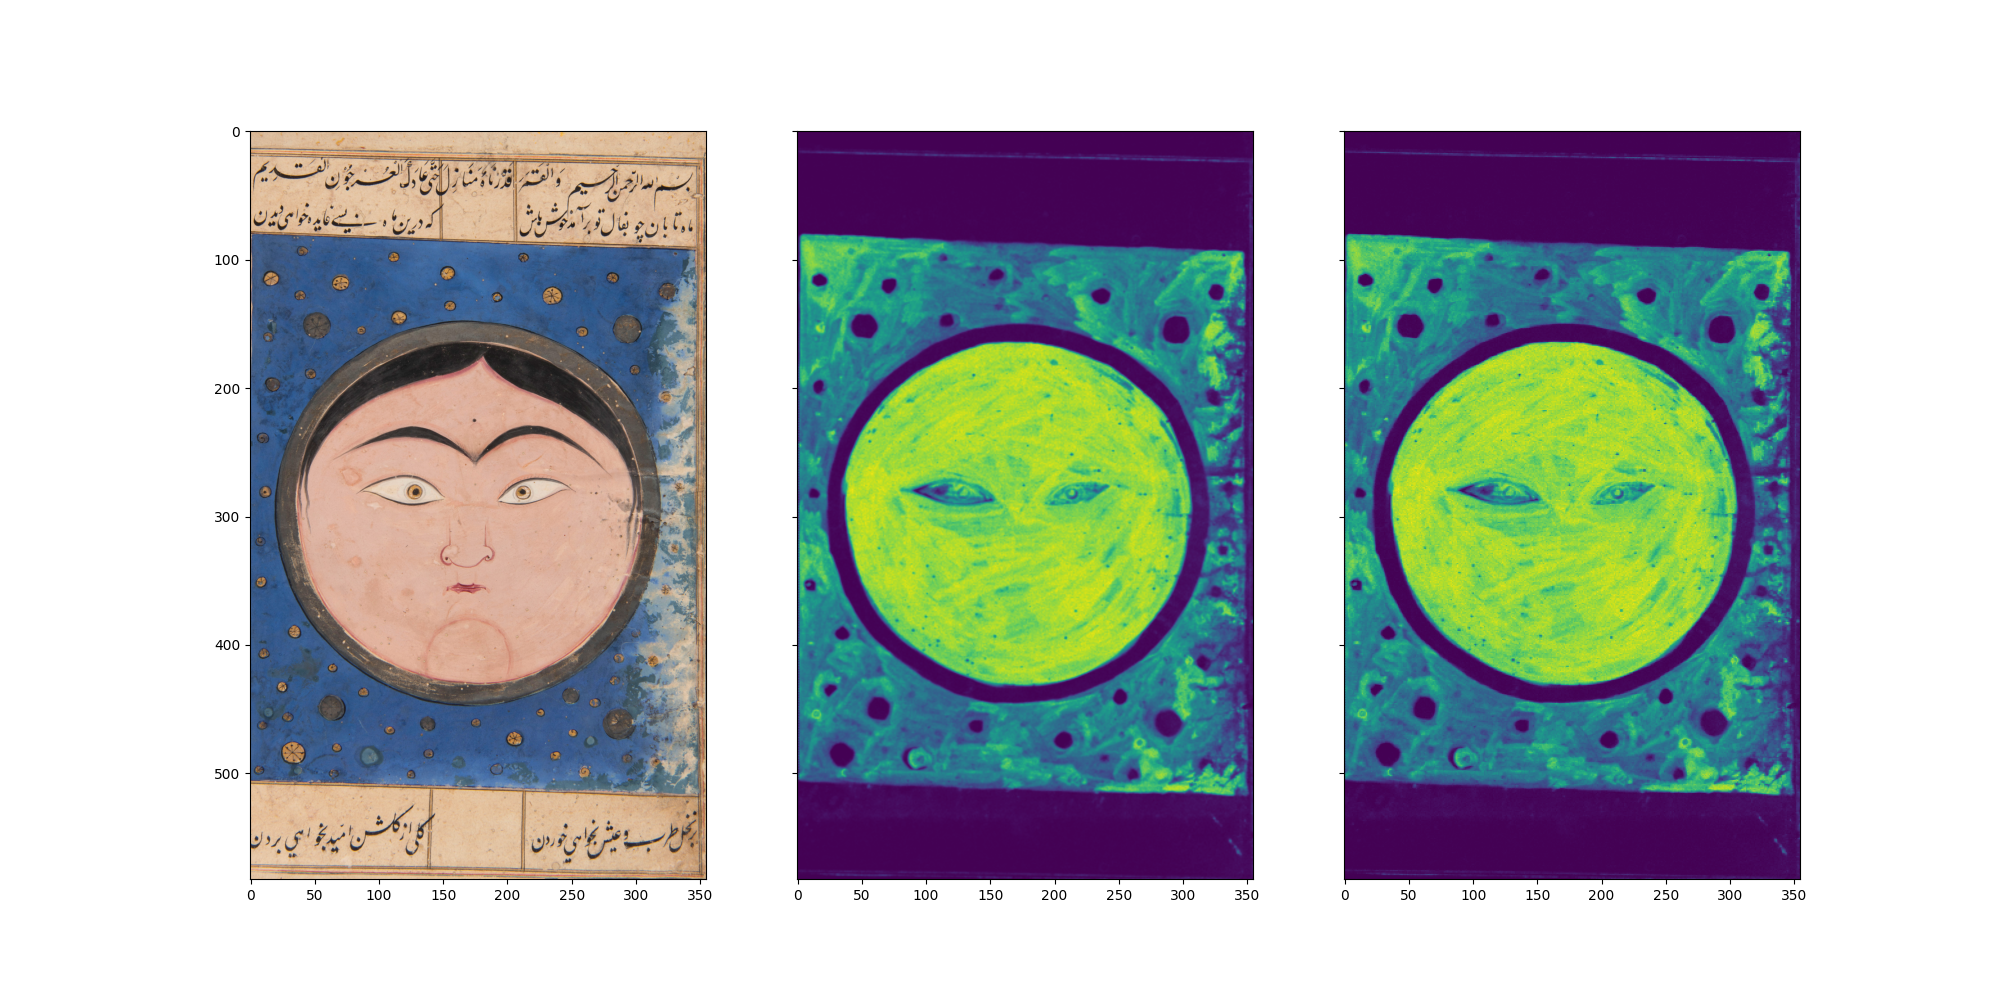

In [27]:
fig, axs = plt.subplots(ncols=3, squeeze=True, sharex=True, sharey=True, figsize=[20, 10])
axs[0].imshow(imvis, extent=extent)
axs[1].imshow(upscaled_map, extent=extent)
axs[2].imshow(Pb_map)

In [15]:
elements = mx.elems_from_atomnums(ds.read('nmf_atomnums'))

In [20]:
h, w, d = imvis.shape

In [21]:
mh, mw = Pb_map.shape

In [22]:
h / mh

14.16123499142367

In [23]:
w / mw

14.16056338028169

In [24]:
import skimage.transform as skt

In [25]:
upscaled_map = skt.resize(Pb_map, [h, w])

In [26]:
upscaled_map.shape

(8256, 5027)